In [2]:
from google.colab import drive
drive.mount('/content/drive')
file_path_test1 = '/content/drive/MyDrive/Projects/Cybersecurity/GUIDE_Test1.csv'
file_path_train = '/content/drive/MyDrive/Projects/Cybersecurity/new_train_sample.csv'
file_path_train2 = '/content/drive/MyDrive/Projects/Cybersecurity/GUIDE_Train1.csv'

Mounted at /content/drive


In [ ]:
# 📦 1. Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 📥 2. Load the Dataset (replace with your full file later)
df = pd.read_csv(file_path_train)  # Rename as per your full dataset later
df.shape

(1048575, 29)

In [ ]:
# Drop rows with missing target
df.dropna(subset=['IncidentGrade'], inplace=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 🔁 4. Encode Target Variable
df['IncidentGrade'].value_counts()
le_target = LabelEncoder()
df['IncidentGrade'] = le_target.fit_transform(df['IncidentGrade'])  # TP=2, FP=0, BP=1 etc.


In [ ]:
# 🔍 5. Handle Categorical Features
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))


In [ ]:
# 📊 6. Define Features and Target
X = df.drop('IncidentGrade', axis=1)
y = df['IncidentGrade']


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# ⚖️ 7. Handle Class Imbalance with SMOTE
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
from xgboost import XGBClassifier

models = [
    ('Random Forest', RandomForestClassifier(n_estimators=400, random_state=56)),
    ('Logistic Regression', LogisticRegression(max_iter=500)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=6, random_state=56)),
    ('KNN', KNeighborsClassifier(n_neighbors=3, metric='manhattan')),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=350, learning_rate=0.01, random_state=55)),
    ('XGBoost', XGBClassifier(n_estimators=350, learning_rate=0.06, use_label_encoder=False, eval_metric='mlogloss', random_state=55))
]

for name, model in models:
    print(f"📌 {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("Macro Precision:", precision_score(y_val, y_pred, average='macro'))
    print("Macro Recall:", recall_score(y_val, y_pred, average='macro'))
    print("Macro F1 Score:", f1_score(y_val, y_pred, average='macro'))
    print("-" * 50)



📌 Random Forest
Accuracy: 0.9304844370289397
Macro Precision: 0.9292480135620022
Macro Recall: 0.9236304470942605
Macro F1 Score: 0.9262829472246877
--------------------------------------------------
📌 Logistic Regression
Accuracy: 0.48373223635003737
Macro Precision: 0.3228802771563502
Macro Recall: 0.39681683056488565
Macro F1 Score: 0.345035575528738
--------------------------------------------------
📌 Decision Tree
Accuracy: 0.674428974167194
Macro Precision: 0.7610317116168271
Macro Recall: 0.5992398299585996
Macro F1 Score: 0.6065009730488119
--------------------------------------------------
📌 KNN
Accuracy: 0.4815219684329632
Macro Precision: 0.45674723726649774
Macro Recall: 0.4353932236082976
Macro F1 Score: 0.4355926084809274
--------------------------------------------------
📌 GradientBoosting
Accuracy: 0.7241911665995435
Macro Precision: 0.7925246015061941
Macro Recall: 0.6585767087037054
Macro F1 Score: 0.6746661802143707
--------------------------------------------------


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# 🤖 8. Train RandomForest Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_res, y_train_res)

In [ ]:
# 📈 9. Evaluate the Model
y_pred = clf.predict(X_val)
print("Macro F1 Score:", f1_score(y_val, y_pred, average='macro'))
print("Precision:", precision_score(y_val, y_pred, average='macro'))
print("Recall:", recall_score(y_val, y_pred, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=le_target.classes_))


Macro F1 Score: 0.9256277465580348
Precision: 0.9272120010632258
Recall: 0.924186100573592

Confusion Matrix:
 [[85826  2120  2377]
 [ 2841 40295  1788]
 [ 3542  1929 67854]]

Classification Report:
                 precision    recall  f1-score   support

BenignPositive       0.93      0.95      0.94     90323
 FalsePositive       0.91      0.90      0.90     44924
  TruePositive       0.94      0.93      0.93     73325

      accuracy                           0.93    208572
     macro avg       0.93      0.92      0.93    208572
  weighted avg       0.93      0.93      0.93    208572



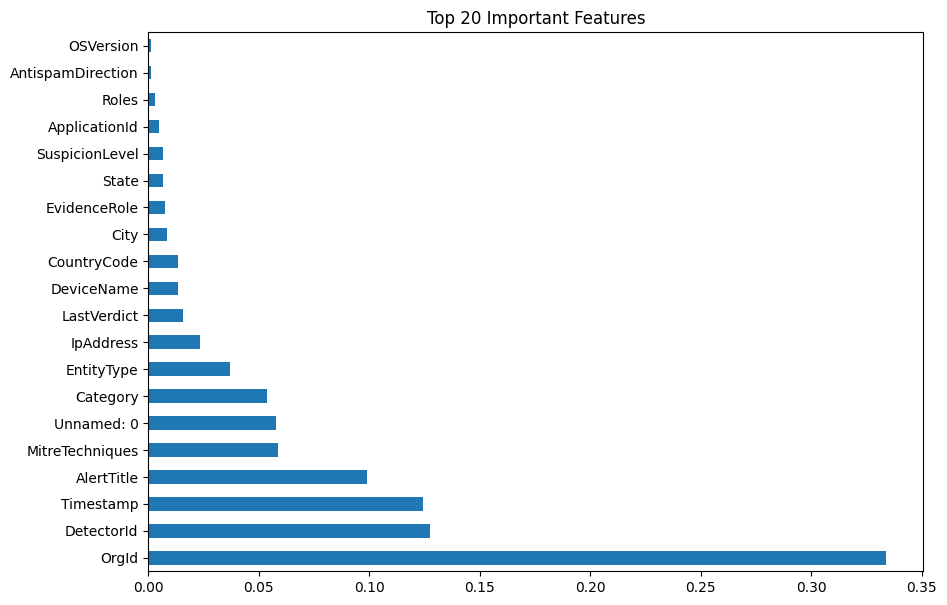

In [ ]:
# 🔎 10. Feature Importance
feat_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.head(20).plot(kind='barh', figsize=(10, 7))
plt.title("Top 20 Important Features")
plt.show()


In [ ]:
# 💾 11. Save the Model
import joblib
joblib.dump(clf, '/content/drive/MyDrive/Projects/Cybersecurity/incident_classifier_model.pkl')
joblib.dump(le_target, '/content/drive/MyDrive/Projects/Cybersecurity/incident_label_encoder.pkl')


NameError: name 'clf' is not defined

In [ ]:
import pandas as pd

# Only read the header
df = pd.read_csv(file_path_train2, nrows=5)
print(df.columns)

Index(['Id', 'OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId',
       'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath',
       'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion',
       'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode',
       'State', 'City'],
      dtype='object')


In [ ]:
selected_columns = [
    'IncidentGrade',  # 🎯 Target
    'Category',
    'AlertTitle',
    'MitreTechniques',
    'ActionGrouped',
    'ActionGranular',
    'EntityType',
    'EvidenceRole',
    'ThreatFamily',
    'OSFamily',
    'OSVersion',
    'SuspicionLevel',
    'CountryCode',
    'State',
    'City'
]


In [ ]:
# 📥 2. Load the Dataset (replace with your full file later)
import pandas as pd
df2 = pd.read_csv(file_path_train,usecols=selected_columns)  # Rename as per your full dataset later
df2.shape

(1048575, 15)

In [ ]:
import pandas as pd

chunk_size = 100_000
file = file_path_train2

# Empty list to collect dataframes
chunks = []

# Read in chunks and store in list
for chunk in pd.read_csv(file, usecols=selected_columns, chunksize=chunk_size):
    # You can process each chunk here before appending if needed
    chunks.append(chunk)

# Combine all chunks into one DataFrame
df1 = pd.concat(chunks, ignore_index=True)

print(df1.head())
print(df1.shape)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Projects/Cybersecurity/GUIDE_Train1.csv'

In [ ]:
df1 = df1.sample(frac=0.4,random_state=42)
df1.shape


(3806735, 15)

In [ ]:
df = df1  + df2

In [ ]:
# Drop rows with missing target
df.dropna(subset=['IncidentGrade'], inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 🔁 4. Encode Target Variable
df1['IncidentGrade'].value_counts()
le_target1 = LabelEncoder()
df1['IncidentGrade'] = le_target1.fit_transform(df1['IncidentGrade'])  # TP=2, FP=0, BP=1 etc.


In [ ]:
# 🔍 5. Handle Categorical Features
cat_cols1 = df1.select_dtypes(include=['object']).columns
for col in cat_cols1:
    df1[col] = df1[col].fillna("Unknown")
    df1[col] = LabelEncoder().fit_transform(df1[col].astype(str))


In [ ]:
# 📊 6. Define Features and Target
X1 = df1.drop('IncidentGrade', axis=1)
y1 = df1['IncidentGrade']

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import KMeansSMOTE

# Example: sample 20% of your data before SMOTE
X_sampled = X1.sample(frac=0.5, random_state=42)
y_sampled = y1.loc[X_sampled.index]

print(X_sampled.shape)
print(y_sampled.shape)
# ⚖️ 7. Handle Class Imbalance with SMOTE
X_train1, X_val1, y_train1, y_val1 = train_test_split(X_sampled, y_sampled, stratify=y_sampled, test_size=0.2, random_state=42)


ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train1, y_train1)

'''smote = KMeansSMOTE(random_state=42)  # supports n_jobs
X_train_res1, y_train_res1 = smote.fit_resample(X_train1, y_train1)'''


(4758418, 14)
(4758418,)


'smote = KMeansSMOTE(random_state=42)  # supports n_jobs\nX_train_res1, y_train_res1 = smote.fit_resample(X_train1, y_train1)'

In [ ]:
drive_path = '/content/drive/MyDrive/Projects/Cybersecurity/chunks'

X_dir = f"{drive_path}/X_chunks"
y_dir = f"{drive_path}/y_chunks"

import math

chunk_size = 500_000
num_chunks = math.ceil(len(X_sampled) / chunk_size)

for i in range(num_chunks):
    print(f"📦 Saving chunk {i+1}/{num_chunks}...")

    X_chunk = X_sampled.iloc[i*chunk_size:(i+1)*chunk_size]
    y_chunk = y_sampled.iloc[i*chunk_size:(i+1)*chunk_size]

    X_chunk.to_pickle(f"{X_dir}/X_chunk_{i}.pkl")
    y_chunk.to_pickle(f"{y_dir}/y_chunk_{i}.pkl")


📦 Saving chunk 1/10...
📦 Saving chunk 2/10...
📦 Saving chunk 3/10...
📦 Saving chunk 4/10...
📦 Saving chunk 5/10...
📦 Saving chunk 6/10...
📦 Saving chunk 7/10...
📦 Saving chunk 8/10...
📦 Saving chunk 9/10...
📦 Saving chunk 10/10...


In [ ]:
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Paths
chunk_dir = "/content/drive/MyDrive/Projects/Cybersecurity/chunks"
model_save_dir = "/content/drive/MyDrive/Projects/Cybersecurity/models"
os.makedirs(model_save_dir, exist_ok=True)

print(os.listdir(chunk_dir + "/X_chunks"))

# Get number of chunks based on files
chunk_files = sorted([f for f in os.listdir(chunk_dir + "/X_chunks") if f.startswith("X_chunk_") and f.endswith(".pkl")])
num_chunks = len(chunk_files)

print(num_chunks)
# Model definitions
def get_models():
    return {
        "random_forest": RandomForestClassifier(n_estimators=300, random_state=42),
        "logistic_regression": LogisticRegression(max_iter=500),
        "decision_tree": DecisionTreeClassifier(max_depth=6, random_state=42),
        "knn": KNeighborsClassifier(n_neighbors=3, metric='manhattan'),
        "xgboost": XGBClassifier(n_estimators=300, learning_rate=0.05,
                                 use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    }

for i in range(num_chunks):
    print(f"\n🔁 Processing chunk {i+1}/{num_chunks}")


    # Load data
    X_chunk = joblib.load(os.path.join(chunk_dir + "/X_chunks/", f"X_chunk_{i}.pkl"))
    y_chunk = joblib.load(os.path.join(chunk_dir + "/y_chunks/", f"y_chunk_{i}.pkl"))

    # Train/Validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X_chunk, y_chunk, test_size=0.2, stratify=y_chunk, random_state=42
    )

    models = get_models()

    for name, model in models.items():
        print(f"🚀 Training {name} on chunk {i+1}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        # Optional: evaluation
        print(f"📊 {name} report for chunk {i+1}:")
        print(classification_report(y_val, y_pred, zero_division=0))

        # Save model
        model_filename = f"{name}_chunk_{i}.pkl"
        joblib.dump(model, os.path.join(model_save_dir, model_filename))
        print(f"✅ Saved: {model_filename}")


['X_chunk_1.pkl', 'X_chunk_2.pkl', 'X_chunk_3.pkl', 'X_chunk_4.pkl', 'X_chunk_5.pkl', 'X_chunk_6.pkl', 'X_chunk_7.pkl', 'X_chunk_8.pkl', 'X_chunk_9.pkl', 'X_chunk_0.pkl']
10

🔁 Processing chunk 1/10
🚀 Training random_forest on chunk 1
📊 random_forest report for chunk 1:
              precision    recall  f1-score   support

           0       0.72      0.90      0.80     43095
           1       0.75      0.51      0.61     21403
           2       0.82      0.72      0.77     34952
           3       0.93      0.98      0.95       550

    accuracy                           0.76    100000
   macro avg       0.80      0.78      0.78    100000
weighted avg       0.76      0.76      0.75    100000

✅ Saved: random_forest_chunk_0.pkl
🚀 Training logistic_regression on chunk 1
📊 logistic_regression report for chunk 1:
              precision    recall  f1-score   support

           0       0.53      0.90      0.67     43095
           1       0.55      0.03      0.06     21403
           2

KeyboardInterrupt: 

In [3]:
import pandas as pd
import joblib
import os
from sklearn.metrics import classification_report
import numpy as np
from sklearn.preprocessing import StandardScaler

# Path to your saved models
model_dir = "/content/drive/MyDrive/Projects/Cybersecurity/models"

# List of models
model_names = ["decision_tree", "logistic_regression", "random_forest", "knn", "xgboost"] # Corrected model names

# Initialize dictionary to store metrics
avg_metrics = {name: {} for name in model_names}

# Iterate over models
for model_name in model_names:
    chunk_reports = []

    # Iterate over 10 chunks
    for i in range(10):
        model_path = os.path.join(model_dir, f"{model_name}_chunk_{i}.pkl")
        # Load pre-trained model
        try:
            model = joblib.load(model_path)
        except FileNotFoundError:
            print(f"Model file not found: {model_path}. Skipping.")
            continue


        # Load corresponding chunk data
        # Assuming your chunk data is in the same directory structure as when saved in cell Ue6MCqx1evGD
        chunk_dir = "/content/drive/MyDrive/Projects/Cybersecurity/chunks"
        X_path = os.path.join(chunk_dir + "/X_chunks/", f"X_chunk_{i}.pkl")
        y_path = os.path.join(chunk_dir + "/y_chunks/", f"y_chunk_{i}.pkl")

        try:
            X = joblib.load(X_path)
            y = joblib.load(y_path)
        except FileNotFoundError:
            print(f"Data files not found for chunk {i}: {X_path}, {y_path}. Skipping.")
            continue


        # Scale features if needed
        if model_name in ["logistic_regression", "knn"]: # Corrected model name
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            y_pred = model.predict(X_scaled)
        else:
            y_pred = model.predict(X)

        # Get classification report as dict
        report = classification_report(y, y_pred, output_dict=True, zero_division=0)
        chunk_reports.append(report)

    # Average metrics across chunks if chunk_reports is not empty
    if chunk_reports:
        # Identify classes
        all_classes = [k for k in chunk_reports[0].keys() if k not in ['accuracy','macro avg','weighted avg']]
        model_avg = {}

        # Average per class
        for cls in all_classes:
            cls_metrics = {metric: np.mean([r[cls][metric] for r in chunk_reports if cls in r and metric in r[cls]])
                           for metric in ['precision','recall','f1-score','support']}
            model_avg[cls] = cls_metrics

        # Average macro and weighted metrics
        for avg_type in ['macro avg','weighted avg']:
            avg_metrics_dict = {metric: np.mean([r[avg_type][metric] for r in chunk_reports if avg_type in r and metric in r[avg_type]])
                                for metric in ['precision','recall','f1-score','support']}
            model_avg[avg_type] = avg_metrics_dict

        # Average accuracy
        model_avg['accuracy'] = np.mean([r['accuracy'] for r in chunk_reports])

        # Save for the model
        avg_metrics[model_name] = model_avg
    else:
        print(f"No reports generated for model {model_name}. Skipping averaging.")


# Optionally, print nicely
import pprint
pprint.pprint(avg_metrics)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist

Model file not found: /content/drive/MyDrive/Projects/Cybersecurity/models/random_forest_chunk_6.pkl. Skipping.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/pytho

{'decision_tree': {'0': {'f1-score': np.float64(0.7094760736718776),
                         'precision': np.float64(0.5872612730977049),
                         'recall': np.float64(0.8959304784065859),
                         'support': np.float64(205492.9)},
                   '1': {'f1-score': np.float64(0.23344420355246026),
                         'precision': np.float64(0.7714420038732734),
                         'recall': np.float64(0.1375386027001228),
                         'support': np.float64(101585.2)},
                   '2': {'f1-score': np.float64(0.6454883516651815),
                         'precision': np.float64(0.6990353830294174),
                         'recall': np.float64(0.5995706447699624),
                         'support': np.float64(166192.8)},
                   '3': {'f1-score': np.float64(0.7801753772818874),
                         'precision': np.float64(0.9690470529893414),
                         'recall': np.float64(0.6539477100900848)

In [4]:
# Convert JSON to DataFrame
summary = {}
for model, metrics in avg_metrics.items():
    summary[model] = {
        "Accuracy": metrics["accuracy"],
        "Macro F1": metrics["macro avg"]["f1-score"],
        "Weighted F1": metrics["weighted avg"]["f1-score"],
        "Macro Precision": metrics["macro avg"]["precision"],
        "Macro Recall": metrics["macro avg"]["recall"]
    }

df_summary = pd.DataFrame(summary).T
print(df_summary)

                     Accuracy  Macro F1  Weighted F1  Macro Precision  \
decision_tree        0.629142  0.592146     0.585840         0.756696   
logistic_regression  0.475973  0.428614     0.447450         0.405577   
random_forest        0.785912  0.816135     0.779860         0.844001   
knn                  0.349237  0.129420     0.180793         0.087309   
xgboost              0.710293  0.732188     0.690622         0.791806   

                     Macro Recall  
decision_tree            0.571747  
logistic_regression      0.513811  
random_forest            0.806819  
knn                      0.250000  
xgboost                  0.731404  
